# Анализ дефолтов МФО и построение системы скоринговых сегментов

**Цель проекта:** Выявить ключевые драйверы дефолтов, сегментировать клиентов по уровню риска и оценить экономический эффект от внедрения правил отсечения.

**Данные:** датасет `microfinance.csv`.

## 1. Загрузка данных и первичный осмотр

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

df = pd.read_csv('../data/microfinance.csv')
df.head()

,age,income,employment_type,credit_history_bad,prev_loans,loan_amount,loan_term_days,region,education,default
0,56.0,60143.0,ИП,0.0,0.0,15426,30,ЕКБ,высшее,0
1,69.0,41902.0,наемный,0.0,2.0,16527,14,НСК,среднее,0
2,46.0,37565.0,наемный,0.0,3.0,13438,30,НСК,высшее,0
3,32.0,26152.0,пенсионер,0.0,5.0,2755,14,НСК,среднее_специальное,0
4,60.0,52979.0,наемный,0.0,0.0,19187,7,НСК,высшее,0


Основная информация о датасете: пропуски, размер, типы

In [3]:
print(f'Размер датасета  {df.shape}')
print()
print('Информация о типах колонок и пропусках')
print()
print(df.info())
print()
print('Пропуски в датасете (в процентах)')
print()
print(df.isnull().sum() / len(df) * 100)
print()

Размер датасета  (10000, 10)

Информация о типах колонок и пропусках

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 9712 non-null   float64
 1   income              9801 non-null   float64
 2   employment_type     9712 non-null   object 
 3   credit_history_bad  9795 non-null   float64
 4   prev_loans          9610 non-null   float64
 5   loan_amount         10000 non-null  int64  
 6   loan_term_days      10000 non-null  int64  
 7   region              9482 non-null   object 
 8   education           9208 non-null   object 
 9   default             10000 non-null  int64  
dtypes: float64(4), int64(3), object(3)
memory usage: 781.4+ KB
None

Пропуски в датасете (в процентах)

age                   2.88
income                1.99
employment_type       2.88
credit_history_bad    2.05
prev_loans           

In [3]:
# Статистика по числовым
df.describe()

,age,income,credit_history_bad,prev_loans,loan_amount,loan_term_days,default
count,9712.000000,9801.000000,9795.000000,9610.000000,10000.000000,10000.000000,10000.000000
mean,43.570531,35436.489440,0.293211,1.997399,10647.219600,17.256300,0.294200
std,14.923040,16220.841727,0.455258,1.408792,6628.513552,7.855596,0.455705
min,18.000000,5000.000000,0.000000,0.000000,506.000000,7.000000,0.000000
25%,31.000000,24527.000000,0.000000,1.000000,5441.500000,14.000000,0.000000
50%,43.000000,36475.000000,0.000000,2.000000,9541.500000,14.000000,0.000000
75%,56.000000,46373.000000,1.000000,3.000000,14881.250000,21.000000,1.000000
max,69.000000,91865.000000,1.000000,10.000000,41012.000000,30.000000,1.000000


default
0    70.58
1    29.42
Name: count, dtype: float64



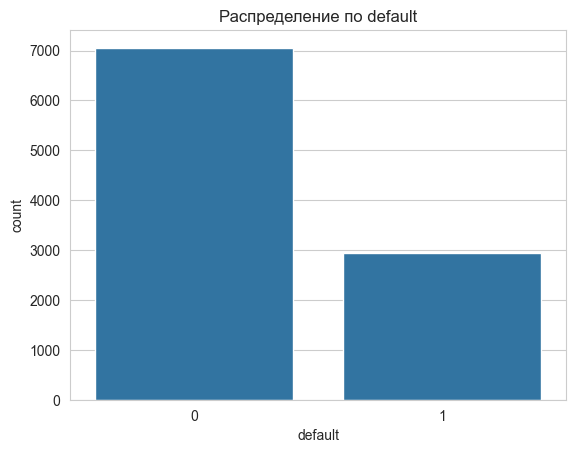

In [4]:
## Распределение целевой переменной

print(df['default'].value_counts() / len(df) * 100);
print()
plt.figure()
sns.countplot(data = df, x= 'default')
plt.title('Распределение по default')
plt.show()

Целевая переменная default имеет дисбаланс: 30% дефолтов против 70% хороших займов. Это характерно для МФО. При валидации нужно исппользовать stratify при разбиении выборки и подбор веса классов при обучении модели.

## 2. Exploratory Data Analysis (EDA)



Гипотезы перед разведочным анализом:

Перед тем как приступить к анализу данных, формулирую гипотезы,
которые буду проверять. После каждого графика, вывод: 
подтверждена гипотеза или опровергнута, и что это значит.

1. Возраст (age).
Самые молодые заёмщики (18 - 28) default'ят чаще. Наиболее надёжная группа (30-45) лет (стабильная занятость, финансовая дисциплина).

2. Доход (income) (слабая связь).
В сегменте МФО доход слабо различает хороших и плохих заёмщиков. Разброс умеренный (CV ≈ 46%), но разделение классов слабое , все клиенты находятся в примерно одинаковой финансовой ситуации. В отличие от банковского кредитования, здесь доход не будет сильным предиктором.

3. Тип занятости (employment_type).
Безработные, не указавшие занятость - самые рисковые категории. Наёмные работники с постоянным контрактом — самые надёжные.

4. Кредитная история (credit_history_bad) (стоп-фактор).
Наличие плохой кредитной истории (credit_history_bad = 1) — сильнейший одиночный предиктор. Клиенты с плохой КИ default'ят в разы чаще, чем клиенты с чистой. Это почти стоп-фактор для выдачи займа.

5. Количество прошлых займов (prev_loans) (нелинейная зависимость).
Новые клиенты (0 займов) - повышенный риск (нет истории). Клиенты с 1-3 займами - самые надёжные (лояльные, рефинансируются). Клиенты с большим количеством займов (6+) - снова повышенный риск (долговая спираль).

6. Сумма займа (loan_amount) - прямая связь с риском.
Чем меньше сумма займа, тем выше вероятность дефолта. Маленькие займы - повышенный риск.

7. Срок займа (loan_term_days) - обратная связь.
Короткие займы («до зарплаты») default'ят чаще, чем длинные. Быстрые деньги на короткий срок берут самые рисковые клиенты.

8. Регион.
Существуют регионы с аномально высоким уровнем дефолта. Региональный фактор значим, и его стоит включать в модель.

9. Образование (слабый признак).
Ожидаю, что различия между уровнями образования будут минимальными. Категория "Не указано" может быть более информативной, чем сами уровни

10. Дневная нагрузка (daily_payment = loan_amount / loan_term_days) самодельная фича.
Сочетание суммы и срока сильнее, чем каждый по отдельности. Высокая дневная нагрузка - зона аномального риска. Это будет один из топ-признаков модели.

Возрастные группы: всего займов и дефолтов
           total  defaults  good
age_group                       
18-24       1282       451   831
25-34       1864       642  1222
35-44       1934       572  1362
45-54       1859       501  1358
55+         2599       614  1985


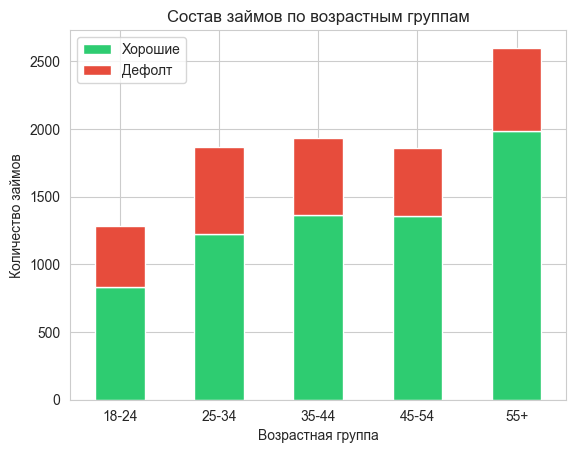

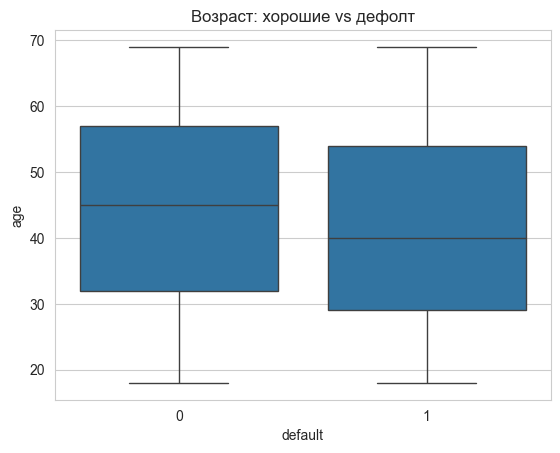

In [47]:
# Делим на возрастные группы
bins = [18, 25, 35, 45, 55, 100]
labels = ['18-24', '25-34', '35-44', '45-54', '55+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

# Всего займов и сколько дефолтов
age_stats = df.groupby('age_group', observed=False).agg(
    total=('default', 'count'),
    defaults=('default', 'sum')
)
age_stats['good'] = age_stats['total'] - age_stats['defaults']

print("Возрастные группы: всего займов и дефолтов")
print(age_stats)

age_stats[['good', 'defaults']].plot(kind='bar', stacked=True, 
                                      color=['#2ecc71', '#e74c3c'])
plt.title('Состав займов по возрастным группам')
plt.xlabel('Возрастная группа')
plt.ylabel('Количество займов')
plt.legend(['Хорошие', 'Дефолт'])
plt.xticks(rotation=0)
plt.show()

#Boxplot
sns.boxplot(x='default', y='age', data=df)
plt.title('Возраст: хорошие vs дефолт')
plt.show()

Вывод: гипотеза подтверждена частично.

Самые рисковые — молодые (18-24).
Самые надёжные — старшие (54+) При большем кол-ве займов.
Старшее поколение занимает реже, но ответственнее. Молодёжь импульсивнее.

Для бизнеса: возраст — рабочий признак, но пороги риска пересматриваем: ужесточаем для 18-34, упрощаем для 45+.

Средний доход по классам
Хорошие: 38130 руб.
Дефолт:   28968 руб.
Разница:  9162 руб.



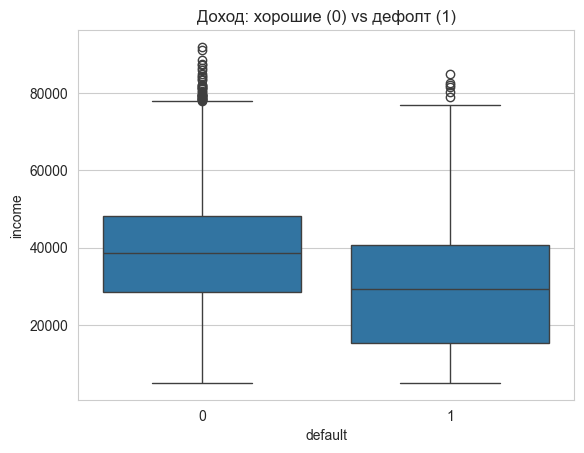

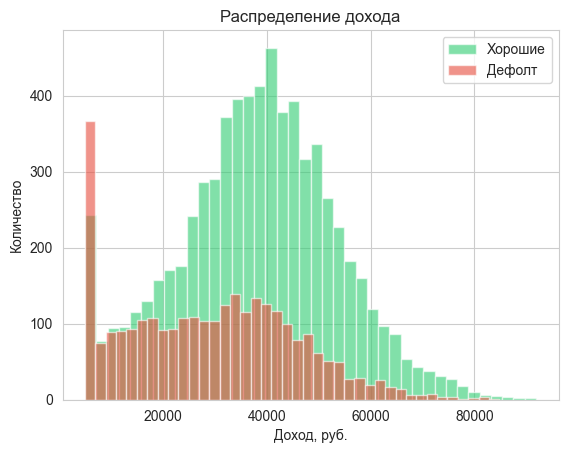

In [13]:
# Доход
#редний доход у хороших и плохих
print("Средний доход по классам")
print(f"Хорошие: {df[df['default']==0]['income'].mean():.0f} руб.")
print(f"Дефолт:   {df[df['default']==1]['income'].mean():.0f} руб.")
print(f"Разница:  {df[df['default']==0]['income'].mean() - df[df['default']==1]['income'].mean():.0f} руб.")
print()
#Boxplot
sns.boxplot(x='default', y='income', data=df)
plt.title('Доход: хорошие (0) vs дефолт (1)')
plt.show()
print()

#Гистограмма
df[df['default']==0]['income'].hist(bins=40, alpha=0.6, label='Хорошие', color='#2ecc71')
df[df['default']==1]['income'].hist(bins=40, alpha=0.6, label='Дефолт', color='#e74c3c')
plt.title('Распределение дохода')
plt.xlabel('Доход, руб.')
plt.ylabel('Количество')
plt.legend()
plt.show()

*Вывод:*
Гипотеза **опровергнута**. Oжидалось, что доход в сегменте МФО слабо влияет на дефолт. 
Данные показали обратное: разница почти в 10 тысяч рублей между классами — это существенно. 
Доход оказался значимым признаком

In [10]:
# По типу занятости
emp_stats = df.groupby('employment_type').agg(Всего = ('default', 'count'), Дефолты= ('default', 'sum'), Рейтинг = ('default', 'mean'))
emp_stats['хорошие'] = emp_stats['Всего'] - emp_stats['Дефолты']
emp_stats

,Всего,Дефолты,Рейтинг,хорошие
employment_type,,,,
ИП,921,172,0.186754,749
безработный,927,528,0.569579,399
наемный,5916,1392,0.235294,4524
пенсионер,996,238,0.238956,758
студент,952,522,0.548319,430


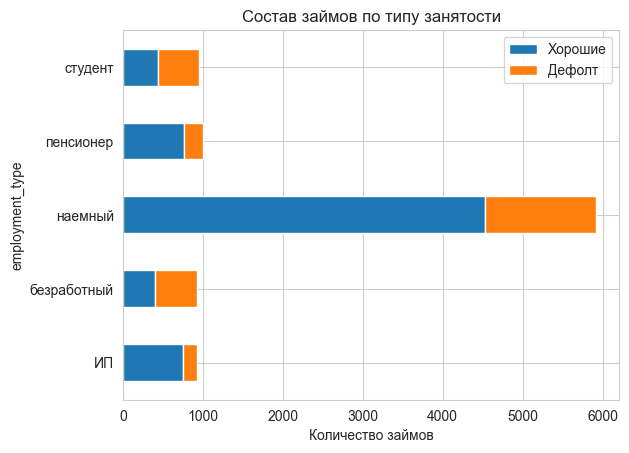

In [36]:
emp_stats[['хорошие','Дефолты']].plot(kind= 'barh', stacked=True)
plt.title('Состав займов по типу занятости')
plt.xlabel('Количество займов')
plt.legend(['Хорошие', 'Дефолт'])
plt.show()

**Вывод:**

Гипотеза подтвердилась частично.

- **Безработные** - ожидаемо высокий риск, 56.9%.
- **Студенты** - неожиданно высокий риск, 54.8%, почти как безработные.
- **Наёмные** - надёжная группа, 23.5%, основа портфеля.
- **Пенсионеры** - стабильные, на уровне наёмных.
- **ИП** - лучшие заёмщики, всего 18.7% дефолтов.

**Для бизнеса:** безработным и студентам - снижать сумму или ручная проверка. Наёмным, пенсионерам и ИП - упрощённое одобрение.

In [9]:
credit_history_stats = df.groupby('credit_history_bad').agg(Всего = ('default', 'count'), Дефолты= ('default', 'sum'), Рейтинг = ('default', 'mean'))
credit_history_stats['Хорошие'] = credit_history_stats['Всего'] - credit_history_stats['Дефолты']
credit_history_stats

,Всего,Дефолты,Рейтинг,Хорошие
credit_history_bad,,,,
0.0,6923,1502,0.216958,5421
1.0,2872,1389,0.483635,1483


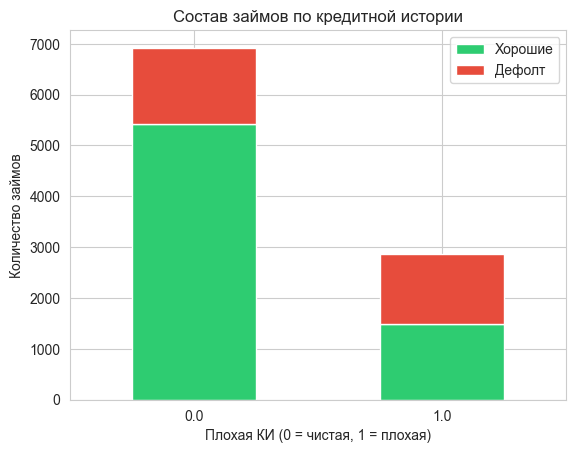

In [8]:
credit_history_stats[['Хорошие', 'Дефолты']].plot(kind='bar', stacked=True, 
                                         color=['#2ecc71', '#e74c3c'])
plt.title('Состав займов по кредитной истории')
plt.xlabel('Плохая КИ (0 = чистая, 1 = плохая)')
plt.ylabel('Количество займов')
plt.legend(['Хорошие', 'Дефолт'])
plt.xticks(rotation=0)
plt.show()

Гипотеза **подтверждена**. Плохая кредитная история — сильнейший одиночный предиктор.

- Клиенты с плохой КИ default'ят в **2.2 раза чаще**: 48.4% против 21.7%.
- Из всех дефолтов почти половина приходится на клиентов с плохой КИ.

`credit_history_bad = 1` - почти стоп-фактор. Таким клиентам либо отказывать, либо выдавать минимальную сумму с обязательной ручной проверкой.

<Axes: >

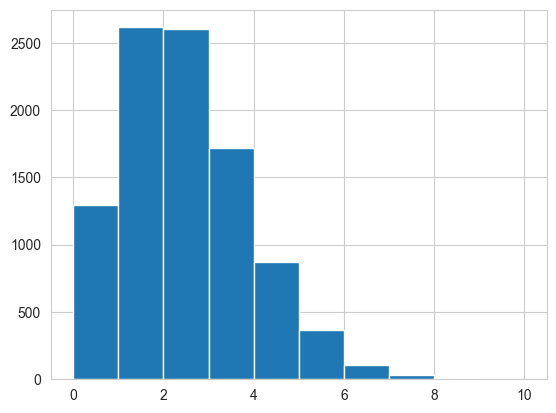

In [12]:
df.prev_loans.hist()

In [16]:
# Разбиваем пред контакты на группы
prev_loans_bins = [-1, 0, 2, 5, float('inf')]
prev_loans_labels = ['0 (новые)', '1-2', '3-5', '6+']

df['prev_loans_groups'] = pd.cut(df['prev_loans'], bins = prev_loans_bins, labels = prev_loans_labels)

In [19]:
prev_loan_stats = df.groupby('prev_loans_groups', observed=False).agg(Всего = ('default', 'count'), Дефолты= ('default', 'sum'), Рейтинг = ('default', 'mean'))
prev_loan_stats['Хорошие'] = prev_loan_stats['Всего'] - prev_loan_stats['Дефолты']
prev_loan_stats

,Всего,Дефолты,Рейтинг,Хорошие
prev_loans_groups,,,,
0 (новые),1294,262,0.202473,1032
1-2,5220,1401,0.268391,3819
3-5,2951,1092,0.370044,1859
6+,145,71,0.489655,74


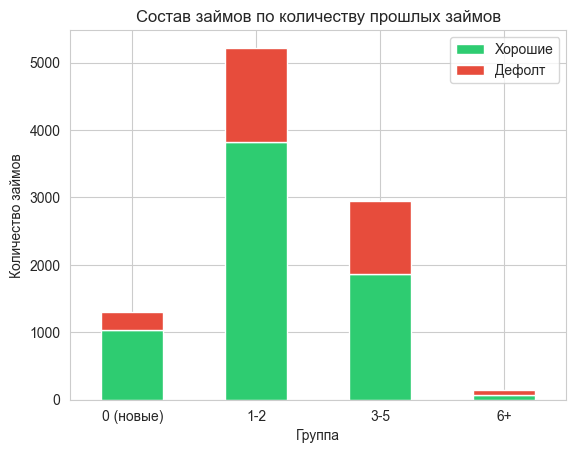

In [22]:
# График
prev_loan_stats[['Хорошие', 'Дефолты']].plot(kind='bar', stacked=True, 
                                       color=['#2ecc71', '#e74c3c'])
plt.title('Состав займов по количеству прошлых займов')
plt.xlabel('Группа')
plt.ylabel('Количество займов')
plt.legend(['Хорошие', 'Дефолт'])
plt.xticks(rotation=0)
plt.show()

Гипотеза **опровергнута**. Ожидалось что новые клиенты рискуют, 1-3 займа надёжны, 6+ снова риск. Данные показали **прямую зависимость**: чем больше прошлых займов, тем выше риск.

- Новые клиенты (0 займов) - лучшие, всего 20.2% дефолтов.
- Клиенты с 6+ займами - худшие, почти 40% дефолтов.
- Каждая следующая группа рискует сильнее предыдущей.

**Что это значит:** большое количество прошлых займов в МФО - не признак лояльности, а признак долговой спирали. Клиенты с 3+ займами уже перегружены.

                   Всего  Дефолты  Хорошие  Рейтинг
loan_amount_group                                  
<5k                 2191     1002     1189     45.7
5-10k               3074      877     2197     28.5
10-15k              2287      574     1713     25.1
15-20k              1441      305     1136     21.2
20k+                1007      184      823     18.3


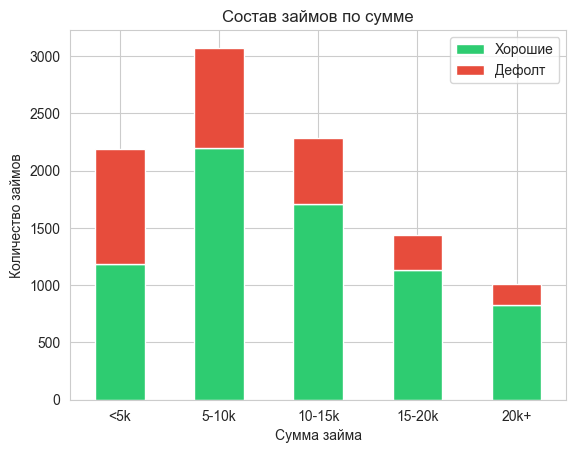

In [25]:
# Сумма займа

## Делим на группы
bins = [0, 5000, 10000, 15000, 20000, 100000]
labels = ['<5k', '5-10k', '10-15k', '15-20k', '20k+']
df['loan_amount_group'] = pd.cut(df['loan_amount'], bins=bins, labels=labels)

# Группировка
amount_stats = df.groupby('loan_amount_group', observed=False).agg(
    Всего=('default', 'count'),
    Дефолты=('default', 'sum')
)
amount_stats['Хорошие'] = amount_stats['Всего'] - amount_stats['Дефолты']
amount_stats['Рейтинг'] = (amount_stats['Дефолты'] / amount_stats['Всего'] * 100).round(1)

print(amount_stats)

# График
amount_stats[['Хорошие', 'Дефолты']].plot(kind='bar', stacked=True, 
                                         color=['#2ecc71', '#e74c3c'])
plt.title('Состав займов по сумме')
plt.xlabel('Сумма займа')
plt.ylabel('Количество займов')
plt.legend(['Хорошие', 'Дефолт'])
plt.xticks(rotation=0)
plt.show()

Гипотеза **подтверждена**, но уточняется направление. Я ожидал «меньше сумма — выше риск», и это именно так.

- Микрозаймы до 5 тысяч - аномально высокий риск, 45.7% дефолтов.
- С ростом суммы риск стабильно снижается: от 28.5% до 18.3%.
- Разница между крайними группами - почти в 2.5 раза.

**Что это значит:** маленькие займы берут самые рисковые клиенты - возможно, impulsive заёмщики или те, кому уже отказали в более крупных суммах. Крупные займы выдаются более тщательно или более надёжным клиентам.

**Для бизнеса:** займы до 5k - зона особого внимания. Возможно, имеет смысл ужесточить скоринг для мелких сумм или наоборот - не тратить ресурсы на проверку, но закладывать высокий риск в ставку.

                Всего  Дефолты  Хорошие  Рейтинг
loan_term_days                                  
7                2024      768     1256     37.9
14               3950     1125     2825     28.5
21               1965      537     1428     27.3
30               2061      512     1549     24.8


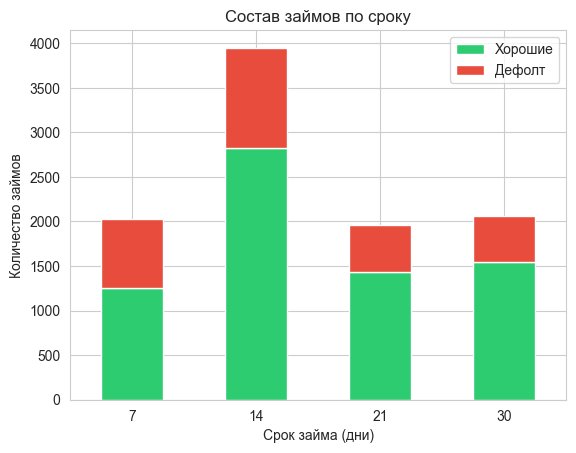

In [33]:
term_stats = df.groupby('loan_term_days').agg(
    Всего=('default', 'count'),
    Дефолты=('default', 'sum')
)
term_stats['Хорошие'] = term_stats['Всего'] - term_stats['Дефолты']
term_stats['Рейтинг'] = (term_stats['Дефолты'] / term_stats['Всего'] * 100).round(1)

print(term_stats)

# График
term_stats[['Хорошие', 'Дефолты']].plot(kind='bar', stacked=True, 
                                          color=['#2ecc71', '#e74c3c'])
plt.title('Состав займов по сроку')
plt.xlabel('Срок займа (дни)')
plt.ylabel('Количество займов')
plt.legend(['Хорошие', 'Дефолт'])
plt.xticks(rotation=0)
plt.show()

Гипотеза **подтверждена**. Чем короче срок, тем выше риск.

- Займы на 7 дней - 37.9% дефолтов, заметно выше среднего.
- Займы на 30 дней - 24.8%, самые надёжные.
- Разница между крайними сроками - 13 п.п.

**Что это значит:** короткие займы «до зарплаты» берут самые рисковые клиенты - те, кому деньги нужны срочно и на короткий срок. Длинные займы - более обдуманные и надёжные.

**Для бизнеса:** срок 7 дней - фактор риска. Можно ужесточать одобрение для таких заявок или повышать ставку. Срок 30 дней - наоборот, признак надёжности.

        Всего  Дефолты  Хорошие  Рейтинг
region                                  
ЕКБ      2278      822     1456     36.1
НСК      3829     1208     2621     31.5
СПб      1432      348     1084     24.3
Москва   1943      421     1522     21.7


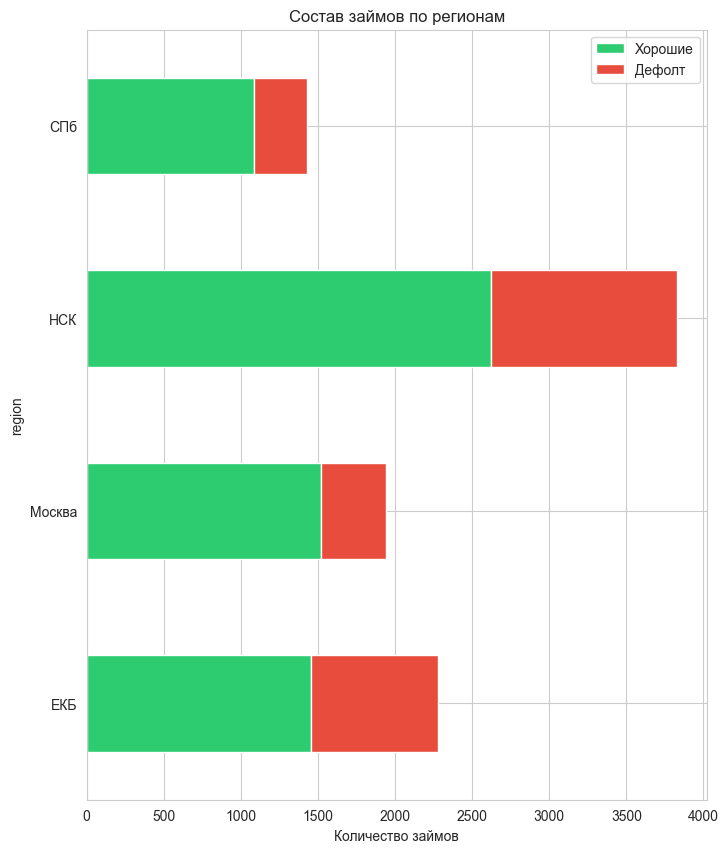

In [35]:
region_stats = df.groupby('region').agg(
    Всего=('default', 'count'),
    Дефолты=('default', 'sum')
)
region_stats['Хорошие'] = region_stats['Всего'] - region_stats['Дефолты']
region_stats['Рейтинг'] = (region_stats['Дефолты'] / region_stats['Всего'] * 100).round(1)

print(region_stats.sort_values('Рейтинг', ascending=False))

# График
region_stats[['Хорошие', 'Дефолты']].plot(kind='barh', stacked=True, 
                                            color=['#2ecc71', '#e74c3c'],
                                            figsize=(8, 10))
plt.title('Состав займов по регионам')
plt.xlabel('Количество займов')
plt.legend(['Хорошие', 'Дефолт'])
plt.show()

Гипотеза **подтверждена**. Есть регионы с аномалиями.

- **ЕКБ** - аномально высокий риск, 36.1%. На 7 п.п. выше среднего.
- **НСК** - чуть выше среднего, 31.5%.
- **Москва** - лучшая, 21.7%. Разница с ЕКБ почти 15 п.п.
- **СПб** - посередине, ближе к Москве.

**Что это значит:** региональный фактор работает. ЕКБ и НСК - зоны повышенного риска, Москва и СПб - пониженного. Возможно, экономическая ситуация в регионах разная.

**Для бизнеса:** регион включаем в модель. Для ЕКБ и НСК можно рассмотреть поправочный коэффициент в скоринге или уменьшение лимитов.

                     Всего  Дефолты  Хорошие  Рейтинг
education                                            
среднее               2694      934     1760     34.7
среднее_специальное   2825      832     1993     29.5
неоконченное           912      268      644     29.4
высшее                2777      665     2112     23.9


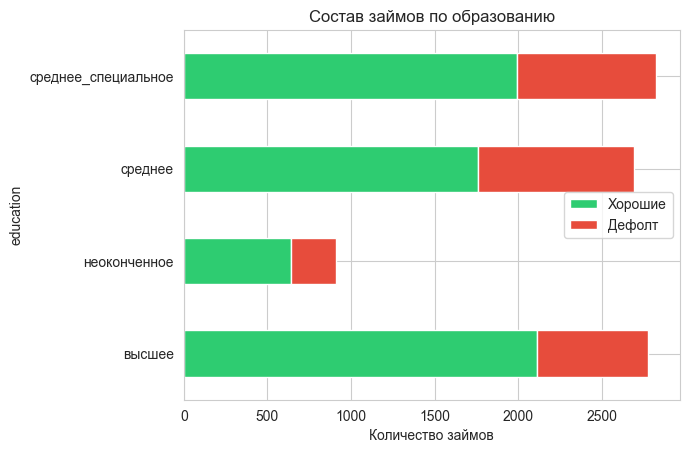

In [36]:
edu_stats = df.groupby('education').agg(
    Всего=('default', 'count'),
    Дефолты=('default', 'sum')
)
edu_stats['Хорошие'] = edu_stats['Всего'] - edu_stats['Дефолты']
edu_stats['Рейтинг'] = (edu_stats['Дефолты'] / edu_stats['Всего'] * 100).round(1)

print(edu_stats.sort_values('Рейтинг', ascending=False))

# График
edu_stats[['Хорошие', 'Дефолты']].plot(kind='barh', stacked=True, 
                                         color=['#2ecc71', '#e74c3c'])
plt.title('Состав займов по образованию')
plt.xlabel('Количество займов')
plt.legend(['Хорошие', 'Дефолт'])
plt.show()

Гипотеза подтверждена частично. Различия между уровнями есть, и они заметнее, чем ожидалось.

- **Среднее образование** - самый высокий риск, 34.7%.
- **Высшее образование** - самый низкий, 23.9%.
- Разница между крайними группами — почти 11 п.п.

**Что это значит:** образование оказалось не слабым, а умеренным признаком. Клиенты с высшим образованием платят дисциплинированнее. Среднее образование - сигнал повышенного риска.

**Для бизнеса:** признак `education` включаем в модель. Клиентам со средним образованием - дополнительная проверка или сниженный лимит.

             Всего  Дефолты  Хорошие  Рейтинг
daily_group                                  
<200          1400      644      756     46.0
200-400       1972      625     1347     31.7
1500+         1236      334      902     27.0
1000-1500     1361      355     1006     26.1
600-800       1372      349     1023     25.4
400-600       1716      420     1296     24.5
800-1000       943      215      728     22.8


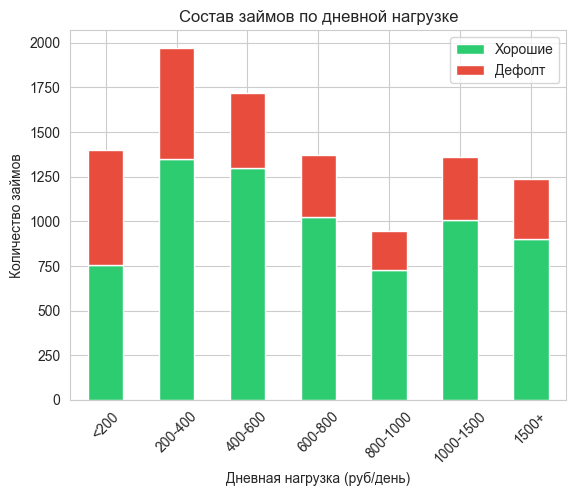

In [46]:
# Создаём признак
df['daily_payment'] = df['loan_amount'] / df['loan_term_days']

# Группы
bins = [0, 200, 400, 600, 800, 1000, 1500, 6000]
labels = ['<200', '200-400', '400-600', '600-800', '800-1000', '1000-1500', '1500+']
df['daily_group'] = pd.cut(df['daily_payment'], bins=bins, labels=labels)

# Считаем
daily_stats = df.groupby('daily_group', observed=False).agg(
    Всего=('default', 'count'),
    Дефолты=('default', 'sum')
)
daily_stats['Хорошие'] = daily_stats['Всего'] - daily_stats['Дефолты']
daily_stats['Рейтинг'] = (daily_stats['Дефолты'] / daily_stats['Всего'] * 100).round(1)

print(daily_stats.sort_values('Рейтинг', ascending=False))

# График
daily_stats[['Хорошие', 'Дефолты']].plot(kind='bar', stacked=True, 
                                           color=['#2ecc71', '#e74c3c'])
plt.title('Состав займов по дневной нагрузке')
plt.xlabel('Дневная нагрузка (руб/день)')
plt.ylabel('Количество займов')
plt.legend(['Хорошие', 'Дефолт'])
plt.xticks(rotation=45)
plt.show()

**Вывод:**

- **Красная зона: <200 руб/день** - 46.0%, аномалия. Микрозаймы на 7 дней, импульсивные клиенты.
- **Зелёная зона: 400-1000 руб/день** - 22.8-25.4%, самая надёжная. Оптимальное сочетание суммы и срока.
- **Жёлтая зона: 200-400 и 1000+** - 26-32%, умеренный риск.

**Для бизнеса:** займы с нагрузкой <200 руб/день - автоматически ограничивать. Признак `daily_payment` - рабочий.

Сводка EDA: проверка гипотез

| № | Признак | Гипотеза | Результат |
|:---|:---|:---|:---|
| Г1 | `default` | Дисбаланс классов | Подтверждена: 29.4% дефолтов, 70.6% хороших |
| Г2 | `age` | Молодые рискуют, 30-45 надёжны | Частично: риск снижается с возрастом монотонно, 55+ — лучшие |
| Г3 | `income` | Слабая связь | Опровергнута: разница 9 162 руб, доход значим |
| Г4 | `employment_type` | Безработные и студенты — зона риска | Подтверждена: 56.9% и 54.8%, наёмные 23.5% |
| Г5 | `credit_history_bad` | Стоп-фактор | Подтверждена: 48.4% vs 21.7%, разница в 2.2 раза |
| Г6 | `prev_loans` | U-образная кривая | Опровергнута: чем больше займов, тем выше риск. Новые — лучшие |
| Г7 | `loan_amount` | Меньше сумма — выше риск | Подтверждена: <5k = 45.7%, 20k+ = 18.3% |
| Г8 | `loan_term_days` | Короче срок — выше риск | Подтверждена: 7 дней = 37.9%, 30 дней = 24.8% |
| Г9 | `region` | Есть регионы-аномалии | Подтверждена: ЕКБ 36.1%, Москва 21.7% |
| Г10 | `education` | Слабый признак | Частично: среднее 34.7%, высшее 23.9% — значим |
| Г11 | `daily_payment` | Высокая нагрузка — риск | Частично: U-образно, <200 = 46%, 400-1000 = зелёная зона |

**Топ-5 признаков по влиянию на дефолт:**

1. `credit_history_bad` — плохая КИ: 48.4% vs 21.7%
2. `daily_payment` < 200 руб/день — 46.0%
3. `loan_amount` < 5k — 45.7%
4. `employment_type` безработный/студент — 55-57%
5. `income` — разница средних 9 162 руб

**Что оказалось неожиданным:**

- Новые клиенты (0 займов) надёжнее повторных — нет долговой спирали
- Доход работает лучше, чем предполагалось
- 55+ самая надёжная возрастная группа
- ИП платят лучше всех (18.7%)
- Образование значимо: разница среднее vs высшее

## Обработка пропусков

Логика замены пропусков

prev_loans - 3.90% пропусков (Заполняем нулём).
Если клиент не указал количество прошлых займов, наиболее вероятная причина - их отсутствие. Клиент с опытом кредитования обычно помнит или указывает это. Заполнение нулём - консервативное и логичное предположение.

credit_history_bad - 2.05% пропусков (Заполняем нулём).
Аналогичная логика. Если клиент нет информации по клиенту, то скорее всего он новый, заполнение нулем - консервативный подход в пользу клиента.

education - 7.92% пропусков (Заменяем категорией).
Самый высокий процент пропусков. Образование часто не указывают при быстрых онлайн-заявках. пометим категорией 'не указано', потому что сам факт отказа указывать образование может коррелировать с риском.

region - 5.18% пропусков (Заполняем модой).
Регион - ещё одно часто пропускаемое поле. Заполнение модой сохраняет типичный профиль клиента.

age - 2.88% пропусков (Заполняем медианой по типу занятости).
Возраст коррелирует с типом занятости студенты моложе, пенсионеры старше, наёмные работники - средний возраст. Медиана по группе employment_type даёт более точное заполнение, чем общая медиана. Остаточные пропуски (если группа полностью пустая) заполняются общей медианой.

income - 1.99% пропусков (Заполняем медианой по типу занятости).
Аналогично с предыдущим пунктом, замена медианной по типо занятости будет простым и адекватным решением.

In [8]:
# «Не указано»
df['education'] = df['education'].fillna('Не указано')
df['region'] = df['region'].fillna('Не указано')
df['employment_type'] = df['employment_type'].fillna('Не указано')

#prev_loans
df['prev_loans'] = df['prev_loans'].fillna(0)

#credit_history_bad
df['credit_history_bad'] = df['credit_history_bad'].fillna(0)

# 4. age - медиана по employment_type
df['age'] = df.groupby('employment_type')['age'].transform(lambda x: x.fillna(x.median()))
df['age'] = df['age'].fillna(df['age'].median())

# 5. income - медиана по employment_type × age_group
df['income'] = df.groupby(['employment_type'])['income'].transform(lambda x: x.fillna(x.median()))
df['income'] = df['income'].fillna(df['income'].median())
# Проверка
print("Осталось пропусков:", df.isnull().sum().sum())

Осталось пропусков: 0


In [9]:
# Делим на возрастные группы
age_bins = [17, 25, 35, 45, 55, 100]
age_labels = ['18-24', '25-34', '35-44', '45-54', '55+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

# Разбиваем пред контакты на группы
prev_loans_bins = [-1, 0, 2, 5, float('inf')]
prev_loans_labels = ['0 (новые)', '1-2', '3-5', '6+']
df['prev_loans_groups'] = pd.cut(df['prev_loans'], bins = prev_loans_bins, labels = prev_loans_labels)